In [1]:
!pip install mysql-connector-python
!pip install SQLAlchemy
!pip install pymysql
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

In [2]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="8303593115",
    database="WEBSITE"
)

df = pd.read_sql("SELECT * FROM website_performance_analytics;", conn)

print(df.head())

conn.close()



   Visitor_ID  Page_Views  Session_Duration  Bounce_Rate  Conversion_Rate  \
0           1           5            711.33         0.57             0.05   
1           2           4            221.40         0.10             0.05   
2           3           4            704.40         0.80             0.03   
3           4           5            695.65         0.26             0.06   
4           5           5             65.83         0.55             0.03   

  Traffic_Source    Exit_Pages  Load_Time Visitor_Type   Location  
0        Organic    Contact Us       1.31          New    Chicago  
1   Social Media      Checkout       2.01    Returning  Charlotte  
2        Organic      Homepage       2.38    Returning  Charlotte  
3         Direct          Blog       2.21          New     Austin  
4       Referral  Product Page       2.22          New   San Jose  


C:\Users\Asus\AppData\Local\Temp\ipykernel_20528\803496165.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM website_performance_analytics;", conn)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5870 entries, 0 to 5869
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Visitor_ID        5870 non-null   int64  
 1   Page_Views        5870 non-null   int64  
 2   Session_Duration  5870 non-null   float64
 3   Bounce_Rate       5870 non-null   float64
 4   Conversion_Rate   5870 non-null   float64
 5   Traffic_Source    5870 non-null   object 
 6   Exit_Pages        5870 non-null   object 
 7   Load_Time         5870 non-null   float64
 8   Visitor_Type      5870 non-null   object 
 9   Location          5870 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 458.7+ KB


In [4]:
df.head()

,Visitor_ID,Page_Views,Session_Duration,Bounce_Rate,Conversion_Rate,Traffic_Source,Exit_Pages,Load_Time,Visitor_Type,Location
0,1,5,711.33,0.57,0.05,Organic,Contact Us,1.31,New,Chicago
1,2,4,221.40,0.10,0.05,Social Media,Checkout,2.01,Returning,Charlotte
2,3,4,704.40,0.80,0.03,Organic,Homepage,2.38,Returning,Charlotte
3,4,5,695.65,0.26,0.06,Direct,Blog,2.21,New,Austin
4,5,5,65.83,0.55,0.03,Referral,Product Page,2.22,New,San Jose


In [5]:
df.shape

(5870, 10)

In [6]:
df.describe()

,Visitor_ID,Page_Views,Session_Duration,Bounce_Rate,Conversion_Rate,Load_Time
count,5870.000000,5870.000000,5870.000000,5870.000000,5870.000000,5870.000000
mean,2935.500000,5.012606,300.018547,0.497293,0.050073,2.004661
std,1694.667371,2.220932,299.313953,0.289158,0.029134,0.496737
min,1.000000,0.000000,0.050000,0.000000,0.000000,-0.050000
25%,1468.250000,3.000000,86.170000,0.240000,0.020000,1.670000
50%,2935.500000,5.000000,205.555000,0.490000,0.050000,2.000000
75%,4402.750000,6.000000,419.032500,0.750000,0.070000,2.350000
max,5870.000000,15.000000,2166.200000,1.000000,0.100000,3.890000


In [7]:
df.columns

Index(['Visitor_ID', 'Page_Views', 'Session_Duration', 'Bounce_Rate',
       'Conversion_Rate', 'Traffic_Source', 'Exit_Pages', 'Load_Time',
       'Visitor_Type', 'Location'],
      dtype='object')

In [8]:
df["Bounce_Rate"] = (df["Bounce_Rate"] * 100).round(0).astype(int)
df["Conversion_Rate"] = (df["Conversion_Rate"] * 100).round(0).astype(int)
print(df[["Bounce_Rate", "Conversion_Rate"]].head())


   Bounce_Rate  Conversion_Rate
0           57                5
1           10                5
2           80                3
3           26                6
4           55                3


In [9]:
df.describe()

,Visitor_ID,Page_Views,Session_Duration,Bounce_Rate,Conversion_Rate,Load_Time
count,5870.000000,5870.000000,5870.000000,5870.000000,5870.000000,5870.000000
mean,2935.500000,5.012606,300.018547,49.729302,5.007325,2.004661
std,1694.667371,2.220932,299.313953,28.915759,2.913377,0.496737
min,1.000000,0.000000,0.050000,0.000000,0.000000,-0.050000
25%,1468.250000,3.000000,86.170000,24.000000,2.000000,1.670000
50%,2935.500000,5.000000,205.555000,49.000000,5.000000,2.000000
75%,4402.750000,6.000000,419.032500,75.000000,7.000000,2.350000
max,5870.000000,15.000000,2166.200000,100.000000,10.000000,3.890000


In [10]:
df["Exit_Pages"].value_counts().head(5)

Exit_Pages
Product Page    1207
Contact Us      1177
Blog            1174
Checkout        1162
Homepage        1150
Name: count, dtype: int64

In [11]:
df.groupby("Traffic_Source")["Conversion_Rate"].mean()

Traffic_Source
Direct          5.084005
Organic         5.034483
Referral        4.918785
Social Media    4.988786
Name: Conversion_Rate, dtype: float64

In [12]:
df.groupby("Visitor_Type")["Bounce_Rate"].mean()

Visitor_Type
New          49.792045
Returning    49.635319
Name: Bounce_Rate, dtype: float64

In [13]:
location_counts = df["Location"].value_counts()

print(location_counts.head) 

<bound method NDFrame.head of Location
San Antonio      317
Charlotte        316
Austin           310
Dallas           308
New York         304
Indianapolis     301
San Francisco    300
Philadelphia     299
Denver           298
Washington       297
Phoenix          297
Houston          293
Fort Worth       291
San Jose         286
Los Angeles      286
Seattle          285
Chicago          281
San Diego        271
Columbus         269
Jacksonville     261
Name: count, dtype: int64>


<Axes: xlabel='Location', ylabel='Bounce_Rate'>

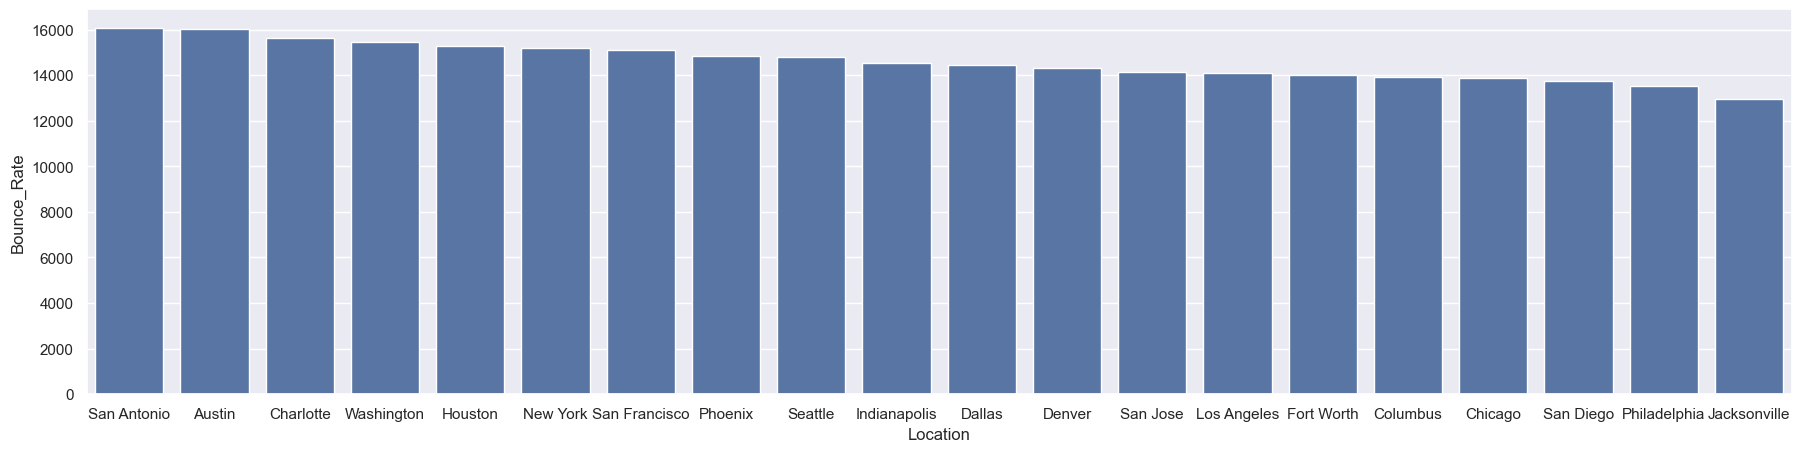

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
State = df.groupby(['Location'], as_index=False)['Bounce_Rate'].sum().sort_values(by = 'Bounce_Rate', ascending=False).head(20)
sns.set(rc={'figure.figsize':(22,5)})
sns.barplot(data = State, x = 'Location', y ='Bounce_Rate')

In [15]:
visitor_counts = df["Visitor_Type"].value_counts()
print(visitor_counts.head)

<bound method NDFrame.head of Visitor_Type
New          3520
Returning    2350
Name: count, dtype: int64>


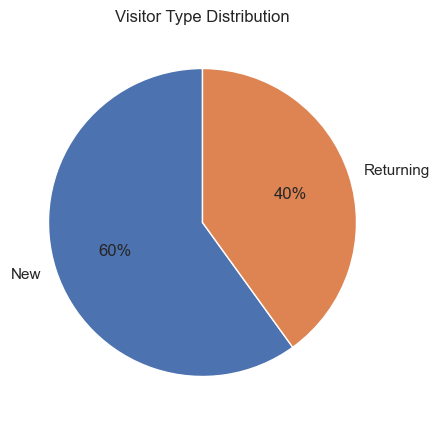

In [16]:
import matplotlib.pyplot as plt
visitor_counts = df["Visitor_Type"].value_counts()
plt.pie(visitor_counts, labels=visitor_counts.index, autopct="%1.0f%%", startangle=90)
plt.title("Visitor Type Distribution")
plt.show()

<Axes: xlabel='Location', ylabel='Session_Duration'>

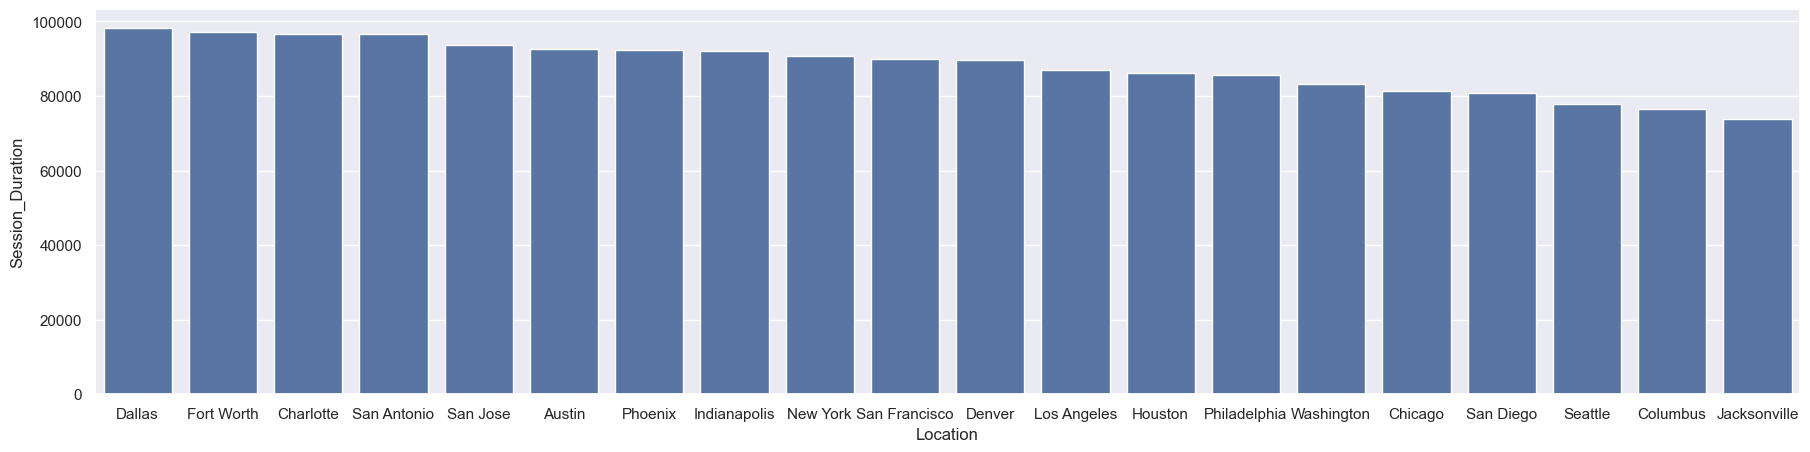

In [17]:
State = df.groupby(['Location'], as_index=False)['Session_Duration'].sum().sort_values(by = 'Session_Duration', ascending=False).head(20)
sns.set(rc={'figure.figsize':(22,5)})
sns.barplot(data = State, x = 'Location', y ='Session_Duration')

In [18]:
pd.crosstab(df['Visitor_Type'], df['Exit_Pages'], normalize='index')*100

Exit_Pages,Blog,Checkout,Contact Us,Homepage,Product Page
Visitor_Type,,,,,
New,20.426136,18.920455,19.687500,19.801136,21.164773
Returning,19.361702,21.106383,20.595745,19.276596,19.659574


<Axes: xlabel='Exit_Pages', ylabel='Bounce_Rate'>

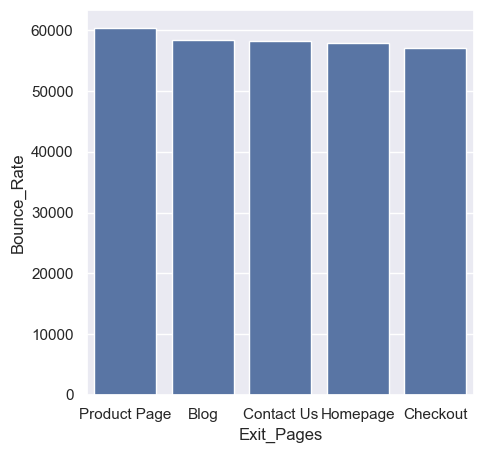

In [19]:
Exit= df.groupby(['Exit_Pages'], as_index=False)['Bounce_Rate'].sum().sort_values(by = 'Bounce_Rate', ascending=False).head(20)
sns.set(rc={'figure.figsize':(5,5)})
sns.barplot(data = Exit, x = 'Exit_Pages', y ='Bounce_Rate')

<Axes: xlabel='Traffic_Source', ylabel='Load_Time'>

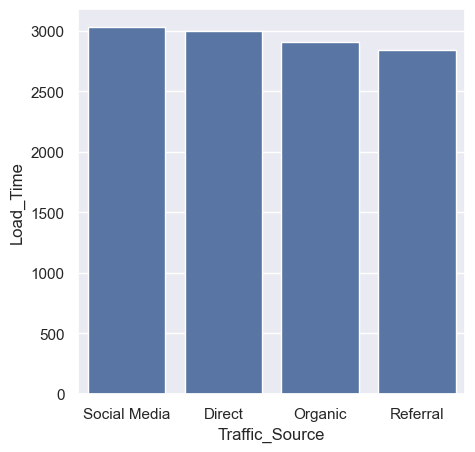

In [20]:
Source= df.groupby(['Traffic_Source'], as_index=False)['Load_Time'].sum().sort_values(by = 'Load_Time', ascending=False).head(20)
sns.set(rc={'figure.figsize':(5,5)})
sns.barplot(data = Source, x = 'Traffic_Source', y ='Load_Time')

<Axes: xlabel='Traffic_Source', ylabel='Bounce_Rate'>

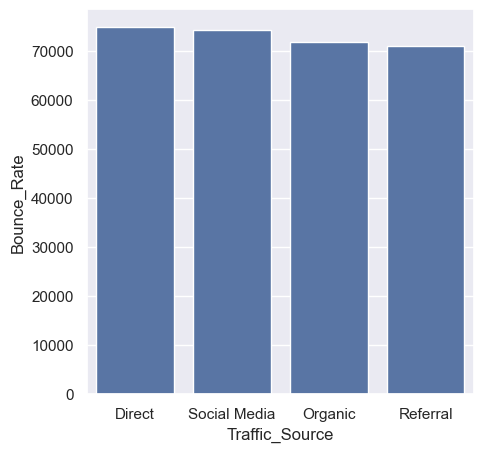

In [21]:
Source= df.groupby(['Traffic_Source'], as_index=False)['Bounce_Rate'].sum().sort_values(by = 'Bounce_Rate', ascending=False).head(20)
sns.set(rc={'figure.figsize':(5,5)})
sns.barplot(data = Source, x = 'Traffic_Source', y ='Bounce_Rate')

<Axes: xlabel='Location', ylabel='Page_Views'>

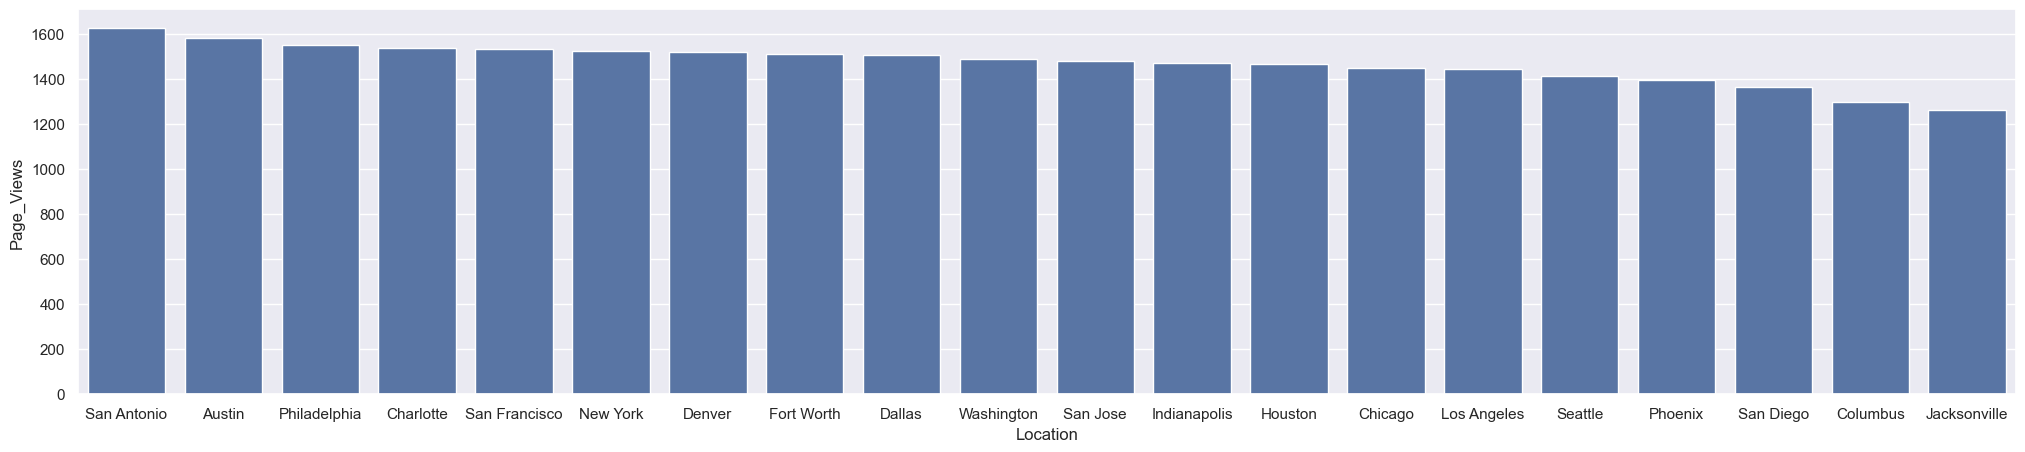

In [22]:
State= df.groupby(['Location'], as_index=False)['Page_Views'].sum().sort_values(by = 'Page_Views', ascending=False).head(20)
sns.set(rc={'figure.figsize':(25,5)})
sns.barplot(data = State, x = 'Location', y ='Page_Views')

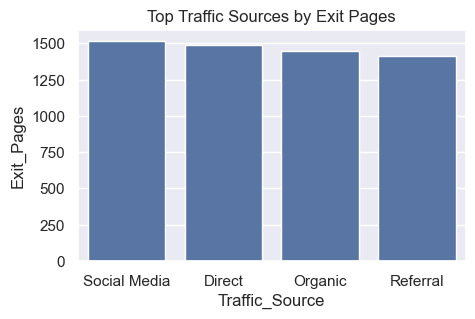

In [23]:
Source = df.groupby("Traffic_Source")["Exit_Pages"].count().reset_index().sort_values(by="Exit_Pages", ascending=False).head(4)

sns.set(rc={'figure.figsize':(5,3)})
sns.barplot(data=Source, x="Traffic_Source", y="Exit_Pages")
plt.title("Top Traffic Sources by Exit Pages")
plt.show()
